# Дипломная работа: Детекция переутомления спортсмена
## Гибридная модель CNN + LSTM на данных носимых датчиков

**Цель:** Разработка системы автоматического определения переутомления спортсмена

**Датасеты (3 источника):**
- **Zenodo Running IMU** (19 субъектов) — бег 400м до/после Beep Test, IMU 256 Hz
- **4TU Marotta** (19 субъектов) — бег 4км + протокол утомления до RPE>16, IMU 240 Hz
- **PhysioNet Wearable Device** (до 31 субъекта) — Empatica E4: ACC(32Hz), BVP(64Hz), EDA(4Hz), TEMP(4Hz), HR(1Hz). Протоколы AEROBIC (cycling) и ANAEROBIC (Wingate)

**Данные (dual-branch):**
- `X_imu`:   (N, 100, 6) — ax, ay, az, gx, gy, gz
- `X_physio`: (N, 100, 4) — bvp, eda, temp, hr
- `has_physio`: маска наличия физиологических каналов

**Модель:** CNN + LSTM (двухветочная, ~474K параметров)
- IMU-ветка: 3×Conv1D → 256-dim
- Physio-ветка: 3×Conv1D → 128-dim
- LSTM: BiLSTM(128) для временной динамики
- Classifier: 384 → 128 → 1

In [1]:
# Imports
import os
import sys
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)

# Add path to afc module
sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

SEED = 5573210

def set_seed(seed=7321):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed fixed: {SEED}")


PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu
Random seed fixed: 5573210


## 2. Загрузка и исследование данных

Загружаем композиционный датасет из `data/processed/composite_full.npz`:
- `X_imu`:   (N, 100, 6) — акселерометр + гироскоп (ax, ay, az, gx, gy, gz)
- `X_physio`: (N, 100, 4) — физиологические каналы (bvp, eda, temp, hr)
- `y`: метки (0=норма, 1=усталость)
- `pids`: ID субъектов ("zenodo_X", "4tu_X", "physionet_X_protocol")
- `domains`: источник ("zenodo", "4tu", "physionet")
- `has_physio`: маска наличия физиологических данных (True для PhysioNet)

In [2]:
# Robust project root detection
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    """Find project root by marker file, moving up the tree."""
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"Marker '{marker}' not found. CWD={os.getcwd()}. "
        f"Run notebook from project directory."
    )

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
RESULTS_DIR = (PROJECT_ROOT / 'results_lstm').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_FILE} (exists={DATA_FILE.exists()})")
print(f"Results dir:  {RESULTS_DIR}")


Project root: D:\Github\afc_lab
Data file:    D:\Github\afc_lab\data\processed\composite_full.npz (exists=True)
Results dir:  D:\Github\afc_lab\results_lstm


In [3]:
# Загрузка композиционного датасета (dual-branch)
print(f"Загрузка данных из {DATA_FILE}...")

data = np.load(DATA_FILE, allow_pickle=True)

X_imu_all = data['X_imu'].astype(np.float32)       # (N, 100, 6)
X_physio_all = data['X_physio'].astype(np.float32)   # (N, 100, 4)
y_all = data['y'].astype(np.int64)                   # (N,)
subjects = data['pids']                               # (N,)
domains = data['domains']                             # (N,)
has_physio = data['has_physio'].astype(bool)           # (N,)
imu_channels = data['imu_channels']                   # ['ax','ay','az','gx','gy','gz']
physio_channels = data['physio_channels']             # ['bvp','eda','temp','hr']

print(f"\n✅ Данные загружены:")
print(f"   X_imu shape:    {X_imu_all.shape}")
print(f"   X_physio shape: {X_physio_all.shape}")
print(f"   y shape:        {y_all.shape}")
print(f"   IMU каналы:     {list(imu_channels)}")
print(f"   Physio каналы:  {list(physio_channels)}")
print(f"   Субъектов:      {len(np.unique(subjects))}")
print(f"   Доменов:        {list(np.unique(domains))}")
print(f"   has_physio:     {has_physio.sum()}/{len(has_physio)} ({has_physio.mean()*100:.1f}%)")


Загрузка данных из D:\Github\afc_lab\data\processed\composite_full.npz...

✅ Данные загружены:
   X_imu shape:    (70898, 100, 6)
   X_physio shape: (70898, 100, 4)
   y shape:        (70898,)
   IMU каналы:     [np.str_('ax'), np.str_('ay'), np.str_('az'), np.str_('gx'), np.str_('gy'), np.str_('gz')]
   Physio каналы:  [np.str_('bvp'), np.str_('eda'), np.str_('temp'), np.str_('hr')]
   Субъектов:      90
   Доменов:        [np.str_('4tu'), np.str_('physionet'), np.str_('zenodo')]
   has_physio:     46030/70898 (64.9%)


In [24]:
df_view = pd.DataFrame(X_imu_all.reshape(X_imu_all.shape[0], -1), columns=[f"{ch}_{t}" for ch in imu_channels for t in range(X_imu_all.shape[1])])
df_view.head(10)

,ax_0,ax_1,ax_2,ax_3,ax_4,ax_5,ax_6,ax_7,ax_8,ax_9,...,gz_90,gz_91,gz_92,gz_93,gz_94,gz_95,gz_96,gz_97,gz_98,gz_99
0,0.114111,-0.698034,-0.416269,0.134061,0.233338,-0.801674,0.301462,-0.642978,0.672917,-0.107133,...,0.750359,-0.122401,-1.062782,-1.560246,0.257955,-0.687226,-0.114013,0.083114,-0.293576,-1.077626
1,0.631300,-0.713949,0.385606,-0.136960,-0.852827,-1.395672,0.715246,-0.715108,0.396508,-0.026430,...,0.552606,0.668905,-1.327065,-0.514125,0.170679,-0.930780,0.479457,0.072117,-1.002151,-1.072949
2,-0.001610,-1.020297,0.598151,0.166494,-0.850925,-1.110366,0.438024,-0.810365,0.734773,-0.255524,...,0.819005,0.405341,-1.286426,-0.200661,0.005663,-0.965260,0.722366,0.340493,-1.040195,-0.745549
3,0.285430,-0.855187,0.827258,0.220782,-1.011662,-0.937312,0.548628,-0.771001,0.818656,-0.030498,...,0.091018,0.107243,-0.406758,-1.251885,0.233711,-0.853198,0.370424,0.340493,-0.721574,-1.016823
4,0.228863,-0.847230,-0.007740,0.695452,-0.576055,-0.977067,0.346781,-0.843539,-0.103000,0.977478,...,1.060296,0.445132,-1.607305,-0.578990,-0.029409,-0.934758,0.473936,0.488045,-0.926062,-0.888202
5,0.458365,-0.926138,0.977696,-0.069866,-1.211394,-1.187539,0.774343,-0.848335,1.039733,-0.323192,...,-0.127299,1.055233,-0.519872,-0.779871,0.350079,-0.919507,0.272433,0.667612,-0.973618,-0.825060
6,0.419576,-0.784236,-0.416269,1.175689,-0.992640,-0.457904,0.305331,-0.819849,-0.797849,1.187739,...,0.310980,0.858582,-0.307295,-1.425672,0.322603,-0.808771,-0.111253,1.111657,-0.700650,-0.906910
7,0.246641,-0.886352,-0.285429,1.185433,-0.433389,-1.192216,0.337182,-0.878375,-0.471739,1.220317,...,-0.085866,1.237105,-0.533803,-1.295680,0.333917,-0.941389,-0.272732,1.296792,-0.479042,-1.238987
8,0.343614,-0.941389,-0.465402,1.455480,-0.616952,-0.963036,0.307061,-0.919882,-0.729022,1.367981,...,0.278065,1.123299,-0.184285,-1.028516,0.325836,-0.939400,-0.162319,1.441560,-0.422926,-1.035532
9,0.304825,-0.973217,-0.024302,1.294008,-0.361104,-0.946666,0.450562,-1.003157,-0.456879,1.296764,...,-0.161120,1.192252,-0.554429,-1.058067,0.330684,-0.953325,-0.104352,1.164553,-0.566544,-0.906910


In [4]:
# Анализ распределения данных
df_meta = pd.DataFrame({
    'sid': subjects,
    'domain': domains,
    'y': y_all,
    'has_physio': has_physio,
})

print("=" * 60)
print("СТАТИСТИКА ДАТАСЕТА")
print("=" * 60)

# Распределение по доменам
print("\n📊 Распределение по источникам данных:")
print(df_meta['domain'].value_counts())

# Распределение по классам
print("\n📊 Распределение по классам (0=норма, 1=усталость):")
print(df_meta['y'].value_counts())
print(f"\nБаланс классов: {df_meta['y'].mean():.2%} положительных")

# Количество субъектов
print(f"\n👥 Уникальных субъектов: {df_meta['sid'].nunique()}")
print("По доменам:")
for domain in sorted(df_meta['domain'].unique()):
    mask = df_meta['domain'] == domain
    n_subj = df_meta[mask]['sid'].nunique()
    n_physio = df_meta[mask]['has_physio'].sum()
    print(f"  - {domain}: {n_subj} субъектов, {mask.sum()} окон, has_physio={n_physio}")


СТАТИСТИКА ДАТАСЕТА

📊 Распределение по источникам данных:
domain
physionet    46030
4tu          18862
zenodo        6006
Name: count, dtype: int64

📊 Распределение по классам (0=норма, 1=усталость):
y
0    38477
1    32421
Name: count, dtype: int64

Баланс классов: 45.73% положительных

👥 Уникальных субъектов: 90
По доменам:
  - 4tu: 8 субъектов, 18862 окон, has_physio=0
  - physionet: 63 субъектов, 46030 окон, has_physio=46030
  - zenodo: 19 субъектов, 6006 окон, has_physio=0


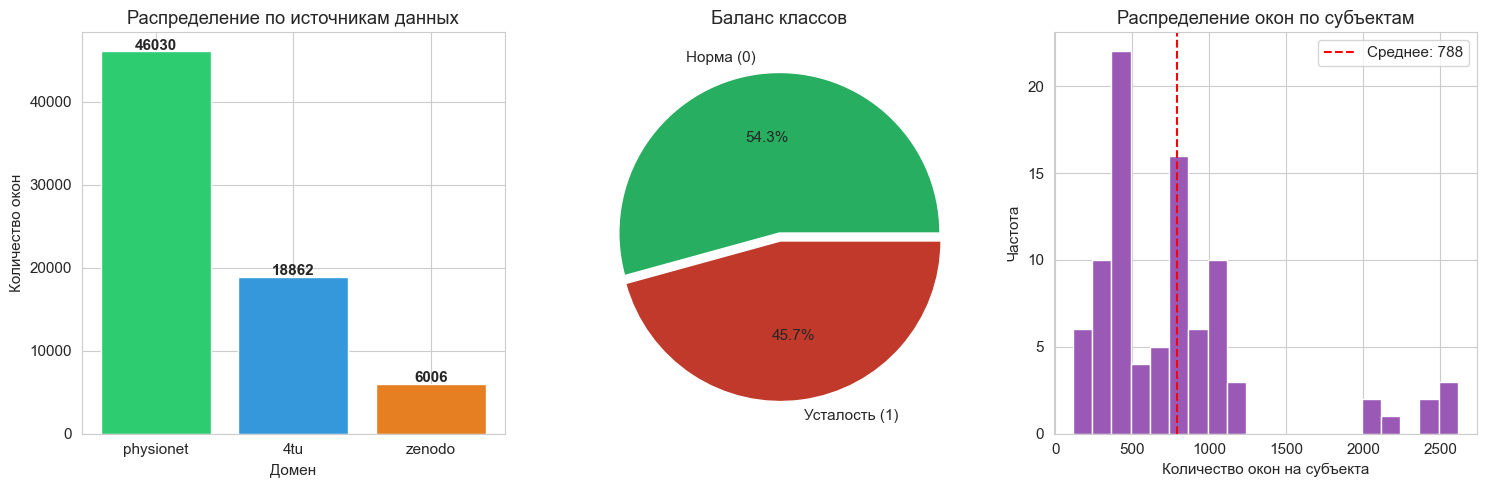

In [5]:
# Визуализация распределений
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Распределение по доменам
domain_counts = df_meta['domain'].value_counts()
colors_domain = ['#2ecc71', '#3498db', '#e67e22'][:len(domain_counts)]
axes[0].bar(domain_counts.index, domain_counts.values, color=colors_domain)
axes[0].set_title('Распределение по источникам данных')
axes[0].set_xlabel('Домен')
axes[0].set_ylabel('Количество окон')
for i, v in enumerate(domain_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Распределение по классам
class_counts = df_meta['y'].value_counts().sort_index()
colors_class = ['#27ae60', '#c0392b']
axes[1].pie(class_counts.values, labels=['Норма (0)', 'Усталость (1)'],
            autopct='%1.1f%%', colors=colors_class, explode=[0, 0.05])
axes[1].set_title('Баланс классов')

# 3. Распределение окон по субъектам
subj_counts = df_meta.groupby('sid').size()
axes[2].hist(subj_counts, bins=20, color='#9b59b6', edgecolor='white')
axes[2].set_title('Распределение окон по субъектам')
axes[2].set_xlabel('Количество окон на субъекта')
axes[2].set_ylabel('Частота')
axes[2].axvline(subj_counts.mean(), color='red', linestyle='--', label=f'Среднее: {subj_counts.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


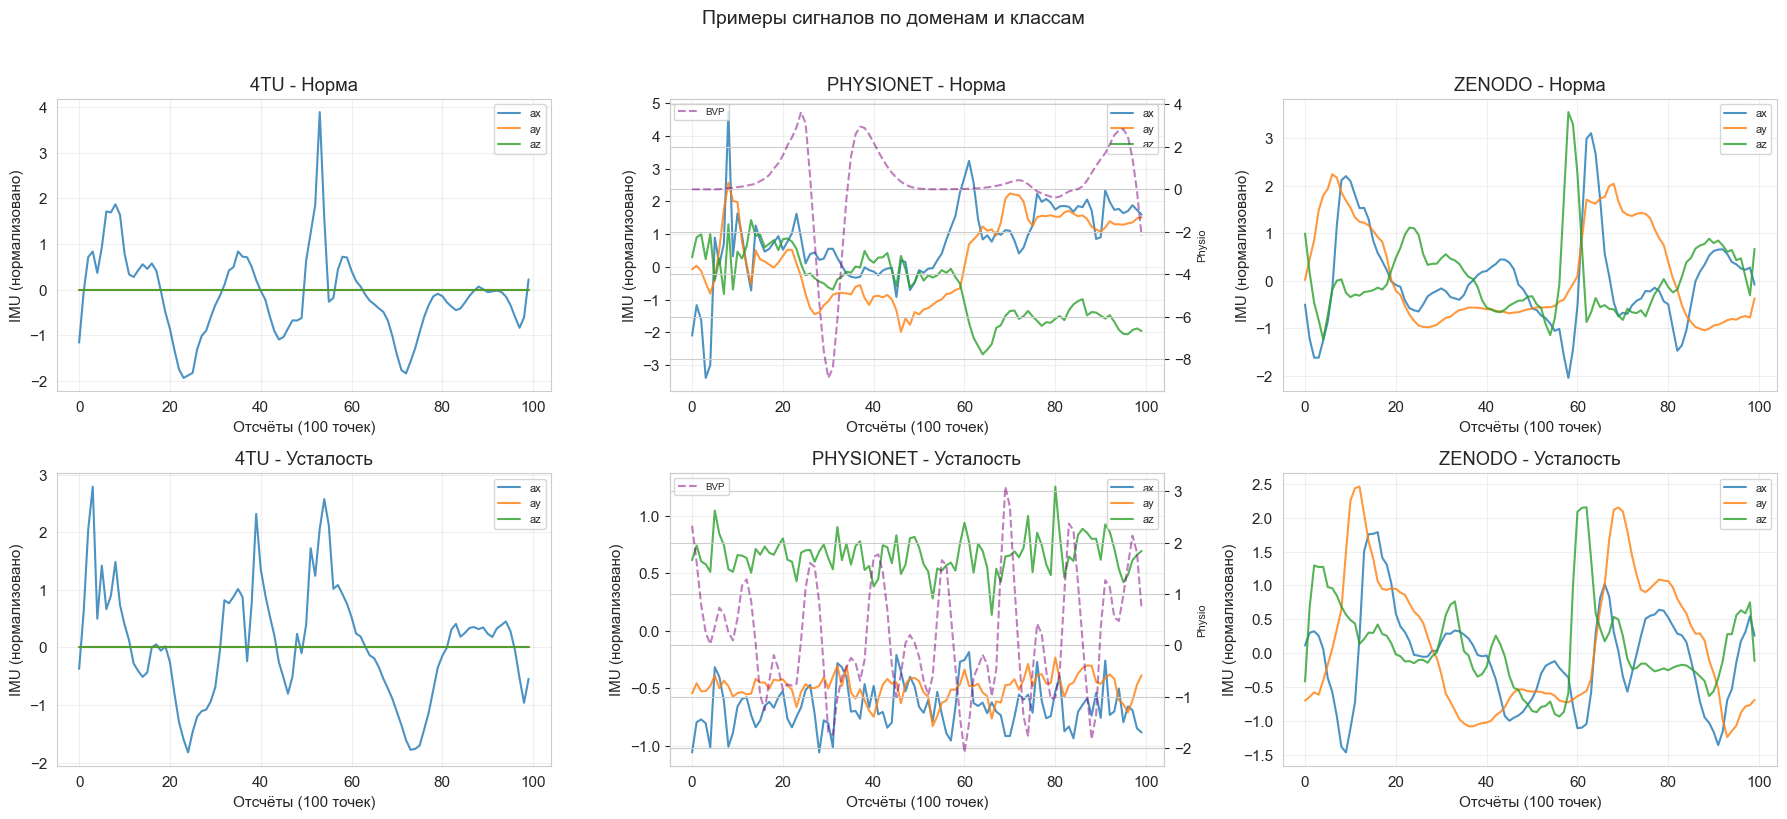

In [6]:
# Визуализация примеров сигналов по доменам
unique_domains = sorted(np.unique(domains))
n_domains = len(unique_domains)
fig, axes = plt.subplots(2, n_domains, figsize=(6 * n_domains, 8))

for col, domain in enumerate(unique_domains):
    domain_mask = domains == domain

    for row, label in enumerate([0, 1]):
        label_mask = y_all == label
        combined_mask = domain_mask & label_mask
        indices = np.where(combined_mask)[0]

        ax = axes[row, col] if n_domains > 1 else axes[row]

        if len(indices) > 0:
            idx = indices[0]
            X = X_imu_all[idx]  # (100, 6)
            time_axis = np.arange(X.shape[0])

            for ch in range(3):  # ax, ay, az
                ax.plot(time_axis, X[:, ch], label=f'a{["x","y","z"][ch]}', alpha=0.8)

            # Если есть physio-данные — отобразим на вторичной оси
            if has_physio[idx]:
                ax2 = ax.twinx()
                Xp = X_physio_all[idx]
                ax2.plot(time_axis, Xp[:, 0], '--', color='purple', alpha=0.5, label='BVP')
                ax2.set_ylabel('Physio', fontsize=8)
                ax2.legend(loc='upper left', fontsize=7)

            status = 'Усталость' if label == 1 else 'Норма'
            ax.set_title(f'{domain.upper()} - {status}')
            ax.set_xlabel('Отсчёты (100 точек)')
            ax.set_ylabel('IMU (нормализовано)')
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)

plt.suptitle('Примеры сигналов по доменам и классам', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'signal_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Подготовка данных для обучения

### 3.1 Формирование фолдов

Используем два подхода к валидации:
1. **LOSO (Leave-One-Subject-Out)** — для оценки обобщающей способности
2. **Train/Val/Test Split** — по субъектам, стратифицировано по доменам

### 3.2 Данные (dual-branch)

Данные уже нормализованы (Z-score по субъектам) при сборке датасета:
- **IMU:** 100 точек × 6 каналов (ax, ay, az, gx, gy, gz)
- **Physio:** 100 точек × 4 канала (bvp, eda, temp, hr) — только для PhysioNet

In [7]:
# Конфигурация данных
IMU_CHANNELS = 6      # ax, ay, az, gx, gy, gz
PHYSIO_CHANNELS = 4   # bvp, eda, temp, hr
TARGET_SAMPLES = 100  # 100 точек на окно

print(f"✅ Данные подготовлены:")
print(f"   X_imu shape:    {X_imu_all.shape}")
print(f"   X_physio shape: {X_physio_all.shape}")
print(f"   y shape:        {y_all.shape}")
print(f"   Субъектов:      {len(np.unique(subjects))}")
print(f"   Доменов:        {len(np.unique(domains))}")
print(f"   has_physio:     {has_physio.sum()}/{len(has_physio)}")
print(f"   NaN (IMU):      {np.isnan(X_imu_all).sum()}")
print(f"   NaN (Physio):   {np.isnan(X_physio_all).sum()}")


✅ Данные подготовлены:
   X_imu shape:    (70898, 100, 6)
   X_physio shape: (70898, 100, 4)
   y shape:        (70898,)
   Субъектов:      90
   Доменов:        3
   has_physio:     46030/70898
   NaN (IMU):      0
   NaN (Physio):   0


In [8]:
# Create LOSO folds
def create_loso_folds(subjects):
    """Create Leave-One-Subject-Out folds."""
    unique_subjects = np.unique(subjects)
    folds = []

    for test_subject in unique_subjects:
        train_mask = subjects != test_subject
        test_mask = subjects == test_subject
        folds.append({
            'train_idx': np.where(train_mask)[0],
            'test_idx': np.where(test_mask)[0],
            'test_subject': test_subject
        })

    return folds


def create_subject_split(subjects, domains, y=None, test_size=0.2, val_size=0.2, random_state=7321):
    """Subject-level split (not window-level), stratified by domain."""
    if test_size + val_size >= 1.0:
        raise ValueError("test_size + val_size must be < 1.0")

    subj_df = pd.DataFrame({'sid': subjects, 'domain': domains}).drop_duplicates(subset='sid')

    # Ensure each subject belongs to a single domain
    dom_counts = subj_df.groupby('sid')['domain'].nunique()
    if (dom_counts > 1).any():
        bad_subjects = dom_counts[dom_counts > 1].index.tolist()
        raise ValueError(f"Subjects mapped to multiple domains: {bad_subjects}")

    sid_values = subj_df['sid'].to_numpy()
    sid_domains = subj_df['domain'].to_numpy()

    strat_test = sid_domains if len(np.unique(sid_domains)) > 1 else None
    sid_train_val, sid_test = train_test_split(
        sid_values,
        test_size=test_size,
        random_state=random_state,
        stratify=strat_test,
    )

    val_rel = val_size / (1.0 - test_size)
    train_val_df = subj_df[subj_df['sid'].isin(sid_train_val)]
    train_val_domains = train_val_df.set_index('sid').loc[sid_train_val, 'domain'].to_numpy()
    strat_val = train_val_domains if len(np.unique(train_val_domains)) > 1 else None

    sid_train, sid_val = train_test_split(
        sid_train_val,
        test_size=val_rel,
        random_state=random_state,
        stratify=strat_val,
    )

    train_idx = np.where(np.isin(subjects, sid_train))[0]
    val_idx = np.where(np.isin(subjects, sid_val))[0]
    test_idx = np.where(np.isin(subjects, sid_test))[0]

    if y is not None:
        for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
            if len(np.unique(y[idx])) < 2:
                raise ValueError(f"Split {name} has one class only. Adjust split parameters.")

    split_info = {
        'train_subjects': sorted(sid_train.tolist()),
        'val_subjects': sorted(sid_val.tolist()),
        'test_subjects': sorted(sid_test.tolist()),
    }
    return train_idx, val_idx, test_idx, split_info


def print_split_summary(name, idx, subjects, domains, y, total_n):
    split_subjects = np.unique(subjects[idx])
    dom_values, dom_counts = np.unique(domains[idx], return_counts=True)
    class_counts = np.bincount(y[idx].astype(int), minlength=2)

    print(f"{name}: {len(idx)} windows ({len(idx)/total_n*100:.1f}%) | subjects: {len(split_subjects)}")
    print(f"  Domains: {dict(zip(dom_values.tolist(), dom_counts.tolist()))}")
    print(f"  Classes: 0 -> {class_counts[0]}, 1 -> {class_counts[1]}, pos_ratio={y[idx].mean():.1%}")


# Build split
train_idx, val_idx, test_idx, split_info = create_subject_split(
    subjects,
    domains,
    y=y_all,
    test_size=0.2,
    val_size=0.2,
    random_state=SEED,
)

print_split_summary('Train', train_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Val', val_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Test', test_idx, subjects, domains, y_all, len(y_all))

print("Subjects by split:")
print(f"  Train ({len(split_info['train_subjects'])}): {', '.join(split_info['train_subjects'])}")
print(f"  Val   ({len(split_info['val_subjects'])}): {', '.join(split_info['val_subjects'])}")
print(f"  Test  ({len(split_info['test_subjects'])}): {', '.join(split_info['test_subjects'])}")


Train: 44856 windows (63.3%) | subjects: 54
  Domains: {'4tu': 12189, 'physionet': 29200, 'zenodo': 3467}
  Classes: 0 -> 24705, 1 -> 20151, pos_ratio=44.9%
Val: 14843 windows (20.9%) | subjects: 18
  Domains: {'4tu': 4547, 'physionet': 8983, 'zenodo': 1313}
  Classes: 0 -> 7990, 1 -> 6853, pos_ratio=46.2%
Test: 11199 windows (15.8%) | subjects: 18
  Domains: {'4tu': 2126, 'physionet': 7847, 'zenodo': 1226}
  Classes: 0 -> 5782, 1 -> 5417, pos_ratio=48.4%
Subjects by split:
  Train (54): 4tu_1, 4tu_3, 4tu_4, 4tu_5, 4tu_7, physionet_S01_aerobic, physionet_S02_anaerobic, physionet_S05_aerobic, physionet_S05_anaerobic, physionet_S06_anaerobic, physionet_S07_anaerobic, physionet_S08_anaerobic, physionet_S09_aerobic, physionet_S10_anaerobic, physionet_S11_anaerobic, physionet_S11a_aerobic, physionet_S13_anaerobic, physionet_S14_aerobic, physionet_S14_anaerobic, physionet_S15_aerobic, physionet_S16_aerobic, physionet_S16b_anaerobic, physionet_S17_aerobic, physionet_S17_anaerobic, physionet_S

## 4. Архитектура модели CNN + LSTM (двухветочная)

### Структура сети FatigueCNN_LSTM:

```
IMU Input (batch, 100, 6) ─────────────────────  Physio Input (batch, 100, 4)
        ↓                                                  ↓
  Conv1D(6→64, k=7)→BN→ReLU→Pool→Drop            Conv1D(4→32, k=7)→BN→ReLU→Pool→Drop
  Conv1D(64→128, k=5)→BN→ReLU→Pool→Drop           Conv1D(32→64, k=5)→BN→ReLU→Pool→Drop
  Conv1D(128→256, k=3)→BN→ReLU→GAP                Conv1D(64→128, k=3)→BN→ReLU→GAP
        ↓ (256-dim)                                        ↓ (128-dim)
        └────────────────── Concat ────────────────────────┘
                              ↓ (384-dim)
                      BiLSTM(hidden=128)
                              ↓ (256-dim)
                  Linear(256→128)→ReLU→Drop
                  Linear(128→1)→Sigmoid
                              ↓
                      Output: P(fatigue)
```

**Параметров:** ~474K (IMU-ветка ~228K + Physio-ветка ~90K + LSTM ~132K + Classifier ~24K)

In [9]:
# ── PyTorch Dataset (dual-branch) ──

class FatigueDataset(Dataset):
    """Dataset for dual-branch fatigue data (IMU + Physio)."""

    def __init__(self, X_imu, X_physio, y, has_physio):
        self.X_imu = torch.FloatTensor(X_imu)
        self.X_physio = torch.FloatTensor(X_physio)
        self.y = torch.FloatTensor(y)
        self.has_physio = torch.BoolTensor(has_physio)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_imu[idx], self.X_physio[idx], self.y[idx], self.has_physio[idx]


# ── CNN + LSTM Model ──

class IMUEncoder(nn.Module):
    """CNN encoder for IMU branch (6-channel input → 256-dim)."""

    def __init__(self, in_channels=6, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        # x: (batch, time, channels) → (batch, channels, time)
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return x.squeeze(-1)  # (batch, 256)


class PhysioEncoder(nn.Module):
    """CNN encoder for Physio branch (4-channel input → 128-dim)."""

    def __init__(self, in_channels=4, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return x.squeeze(-1)  # (batch, 128)


class FatigueCNN_LSTM(nn.Module):
    """
    Dual-branch CNN + LSTM for fatigue detection.

    IMU branch:    (batch, 100, 6) → Conv1D → 256-dim
    Physio branch: (batch, 100, 4) → Conv1D → 128-dim
    Fusion:        concat → 384-dim → BiLSTM → classifier
    """

    def __init__(self, imu_channels=6, physio_channels=4,
                 lstm_hidden=128, lstm_layers=1, dropout=0.3):
        super().__init__()

        self.imu_encoder = IMUEncoder(in_channels=imu_channels, dropout=0.2)
        self.physio_encoder = PhysioEncoder(in_channels=physio_channels, dropout=0.2)

        # Fusion dimension: 256 (IMU) + 128 (Physio) = 384
        fusion_dim = 256 + 128

        # BiLSTM over fused representation
        self.lstm = nn.LSTM(
            input_size=fusion_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        # Classifier: BiLSTM output = 2 * hidden
        lstm_out_dim = lstm_hidden * 2
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x_imu, x_physio, has_physio=None):
        """
        Args:
            x_imu:      (batch, 100, 6)
            x_physio:   (batch, 100, 4)
            has_physio:  (batch,) bool — mask physio branch with zeros where unavailable

        Returns:
            logits: (batch,)
        """
        imu_feat = self.imu_encoder(x_imu)       # (batch, 256)
        physio_feat = self.physio_encoder(x_physio)  # (batch, 128)

        # Zero-out physio features if physio data is absent
        if has_physio is not None:
            mask = has_physio.float().unsqueeze(-1)  # (batch, 1)
            physio_feat = physio_feat * mask

        fused = torch.cat([imu_feat, physio_feat], dim=1)  # (batch, 384)

        # LSTM expects (batch, seq_len, features) — treat as single-step sequence
        fused = fused.unsqueeze(1)   # (batch, 1, 384)
        lstm_out, _ = self.lstm(fused)  # (batch, 1, 256)
        lstm_out = lstm_out.squeeze(1)  # (batch, 256)

        logits = self.classifier(lstm_out)
        return logits.squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None):
        with torch.no_grad():
            logits = self.forward(x_imu, x_physio, has_physio)
            return torch.sigmoid(logits)


# ── Create model and print info ──
model = FatigueCNN_LSTM(
    imu_channels=IMU_CHANNELS,
    physio_channels=PHYSIO_CHANNELS,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Per-component stats
imu_params = sum(p.numel() for p in model.imu_encoder.parameters())
physio_params = sum(p.numel() for p in model.physio_encoder.parameters())
lstm_params = sum(p.numel() for p in model.lstm.parameters())
cls_params = sum(p.numel() for p in model.classifier.parameters())

print("=" * 60)
print("MODEL ARCHITECTURE: FatigueCNN_LSTM")
print("=" * 60)
print(model)
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"  IMU encoder:    {imu_params:,}")
print(f"  Physio encoder: {physio_params:,}")
print(f"  LSTM:           {lstm_params:,}")
print(f"  Classifier:     {cls_params:,}")


MODEL ARCHITECTURE: FatigueCNN_LSTM
FatigueCNN_LSTM(
  (imu_encoder): IMUEncoder(
    (conv1): Sequential(
      (0): Conv1d(6, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Dropout(p=0.2, inplace=False)
    )
    (conv2): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Dropout(p=0.2, inplace=False)
    )
    (conv3): Sequential(
      (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tru

## 5. Обучение модели CNN + LSTM

### Конфигурация обучения:
- **Оптимизатор:** AdamW (weight_decay=1e-4)
- **Learning Rate:** 0.001 с Cosine Annealing
- **Loss:** BCEWithLogitsLoss с весами классов
- **Batch Size:** 64
- **Epochs:** 50 (с Early Stopping, patience=10)
- **Gradient Clipping:** max_norm=1.0

In [10]:
# Training configuration
CONFIG = {
    'batch_size': 64,
    'epochs': 50,
    'lr': 0.001,
    'weight_decay': 1e-4,
    'patience': 10,
    'min_delta': 1e-3,
}


def compute_class_weights(y):
    """Compute positive class weight for BCEWithLogitsLoss."""
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    if n_pos == 0 or n_neg == 0:
        return 1.0
    return n_neg / n_pos


class EarlyStopping:
    """Early stopping by metric where higher is better (e.g., F1)."""

    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None

    def __call__(self, score, model):
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def format_metric(value):
    return f"{value:.4f}" if np.isfinite(value) else "nan"


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    """Compute binary metrics with edge-case handling."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }

    if np.unique(y_true).size < 2:
        metrics['roc_auc'] = np.nan
        metrics['pr_auc'] = np.nan
    else:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(recall_vals, precision_vals)

    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    """Select threshold by best F1-macro on validation."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    best_threshold, best_f1 = 0.5, -np.inf
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_prob >= threshold).astype(int)
        current_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(threshold)
    return best_threshold, best_f1


def train_epoch(model, loader, optimizer, criterion, device):
    """Train one epoch (dual-branch)."""
    model.train()
    total_loss = 0.0

    for X_imu, X_physio, y_batch, hp_batch in loader:
        X_imu = X_imu.to(device)
        X_physio = X_physio.to(device)
        y_batch = y_batch.to(device)
        hp_batch = hp_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_imu, X_physio, hp_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    """Validate model (dual-branch)."""
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_imu, X_physio, y_batch, hp_batch in loader:
            X_imu = X_imu.to(device)
            X_physio = X_physio.to(device)
            y_batch = y_batch.to(device)
            hp_batch = hp_batch.to(device)

            logits = model(X_imu, X_physio, hp_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)

            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_probs = np.array(all_probs, dtype=np.float32)
    all_labels = np.array(all_labels, dtype=np.int64)
    metrics, _ = compute_binary_metrics(all_labels, all_probs, threshold=threshold)

    if return_raw:
        return avg_loss, metrics, all_labels, all_probs
    return avg_loss, metrics


print("Training utilities ready (dual-branch)")


Training utilities ready (dual-branch)


In [11]:
# Prepare data for training (dual-branch)
train_dataset = FatigueDataset(
    X_imu_all[train_idx], X_physio_all[train_idx],
    y_all[train_idx], has_physio[train_idx],
)
val_dataset = FatigueDataset(
    X_imu_all[val_idx], X_physio_all[val_idx],
    y_all[val_idx], has_physio[val_idx],
)
test_dataset = FatigueDataset(
    X_imu_all[test_idx], X_physio_all[test_idx],
    y_all[test_idx], has_physio[test_idx],
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")

# Initialize model
model = FatigueCNN_LSTM(
    imu_channels=IMU_CHANNELS,
    physio_channels=PHYSIO_CHANNELS,
).to(DEVICE)

# Class weights
pos_weight = compute_class_weights(y_all[train_idx])
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
print(f"\nPositive class weight: {pos_weight:.2f}")

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

# Early stopping by F1
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])


Train: 44856 samples, 701 batches
Val:   14843 samples, 232 batches
Test:  11199 samples, 175 batches

Positive class weight: 1.23


In [12]:
# Train CNN + LSTM model
print("=" * 60)
print("TRAINING CNN + LSTM")
print("=" * 60)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
    'lr': [],
}

best_val_f1 = -np.inf
best_epoch = 0
best_threshold = 0.5
best_threshold_f1 = -np.inf

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_metrics, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, threshold=0.5, return_raw=True,
    )

    val_f1 = val_metrics['f1_macro']
    val_auc = val_metrics['roc_auc']
    val_pr_auc = val_metrics['pr_auc']
    val_bal_acc = val_metrics['balanced_acc']

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    history['val_pr_auc'].append(val_pr_auc)
    history['val_bal_acc'].append(val_bal_acc)
    history['lr'].append(current_lr)

    if val_f1 > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        best_threshold, best_threshold_f1 = find_best_threshold(val_labels, val_probs)
        torch.save(model.state_dict(), RESULTS_DIR / 'best_model_lstm.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Val AUC: {format_metric(val_auc)} | "
            f"LR: {current_lr:.6f}"
        )

    if early_stopping(val_f1, model):
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

# Restore best
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print(f"\nTraining completed")
print(f"Best epoch: {best_epoch}, Val F1: {best_val_f1:.4f}")
print(f"Best threshold: {best_threshold:.3f} (F1={best_threshold_f1:.4f})")


TRAINING CNN + LSTM
Epoch   1/50 | Train Loss: 0.4092 | Val Loss: 0.7013 | Val F1: 0.7097 | Val AUC: 0.8310 | LR: 0.000999
Epoch   5/50 | Train Loss: 0.2014 | Val Loss: 0.9209 | Val F1: 0.7008 | Val AUC: 0.8159 | LR: 0.000976
Epoch  10/50 | Train Loss: 0.1458 | Val Loss: 1.1334 | Val F1: 0.6939 | Val AUC: 0.7986 | LR: 0.000905
Epoch  15/50 | Train Loss: 0.1206 | Val Loss: 1.3145 | Val F1: 0.7066 | Val AUC: 0.8134 | LR: 0.000794
Epoch  20/50 | Train Loss: 0.1003 | Val Loss: 1.3700 | Val F1: 0.7165 | Val AUC: 0.8212 | LR: 0.000655
Epoch  25/50 | Train Loss: 0.0864 | Val Loss: 1.4187 | Val F1: 0.7397 | Val AUC: 0.8213 | LR: 0.000500
Epoch  30/50 | Train Loss: 0.0748 | Val Loss: 1.5828 | Val F1: 0.7183 | Val AUC: 0.8180 | LR: 0.000346
Epoch  35/50 | Train Loss: 0.0675 | Val Loss: 1.6851 | Val F1: 0.7333 | Val AUC: 0.8180 | LR: 0.000207

Early stopping at epoch 37

Training completed
Best epoch: 27, Val F1: 0.7569
Best threshold: 0.575 (F1=0.7582)


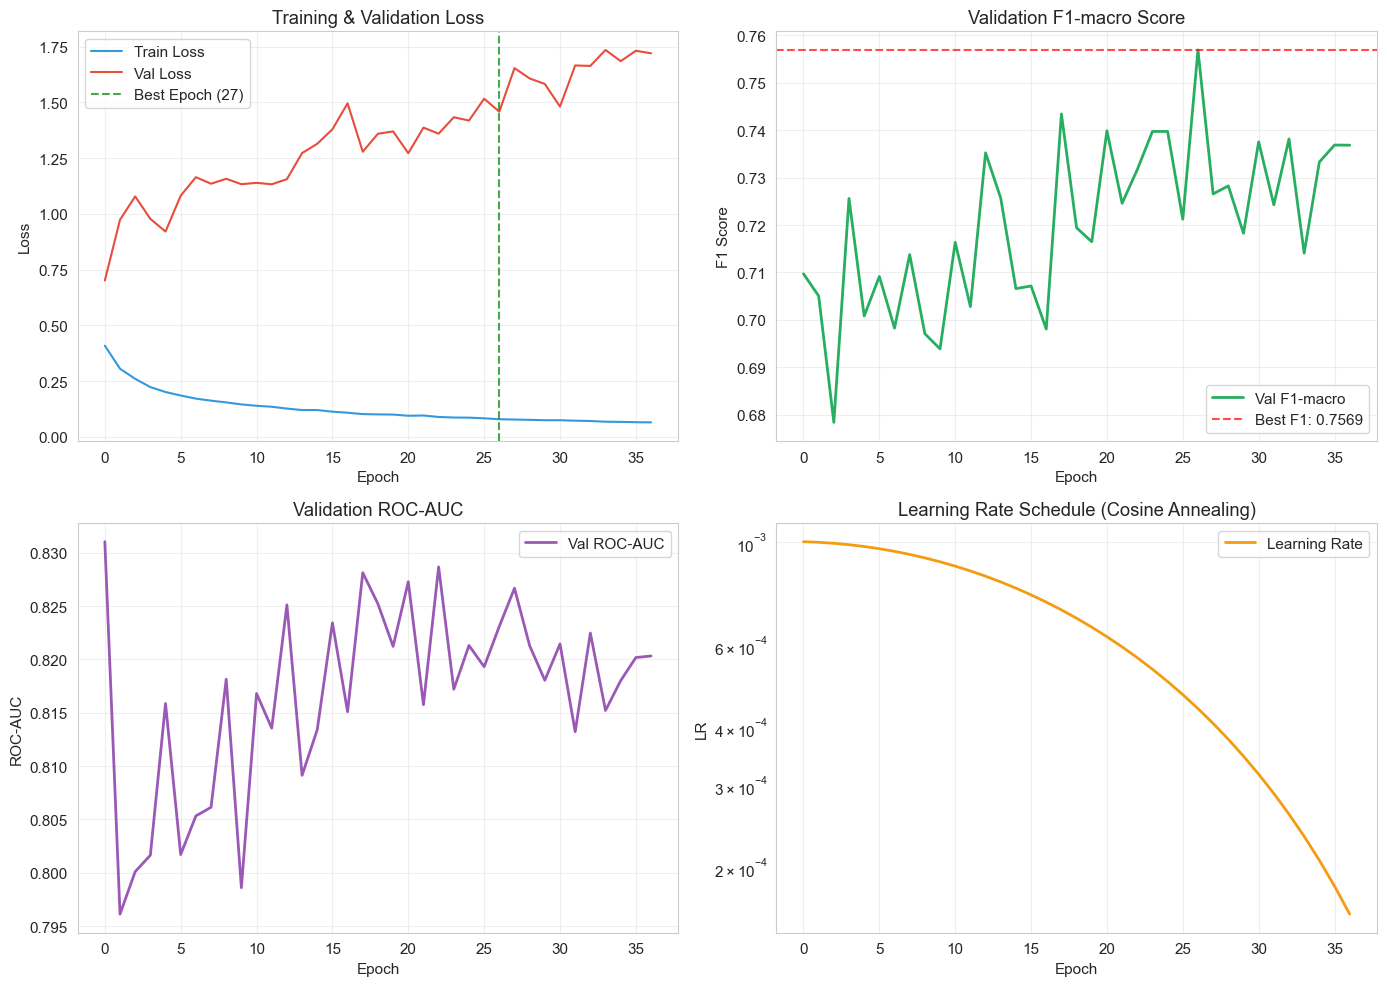

In [13]:
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Оценка модели на тестовых данных

Загружаем лучшую модель и оцениваем на тестовой выборке:
- Confusion Matrix
- Classification Report
- ROC Curve
- Precision-Recall Curve

In [14]:
# Загрузка лучшей модели и оценка на тестовой выборке
model.load_state_dict(torch.load(RESULTS_DIR / 'best_model_lstm.pth', weights_only=True))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_imu, X_physio, y_batch, hp_batch in test_loader:
        X_imu = X_imu.to(DEVICE)
        X_physio = X_physio.to(DEVICE)
        hp_batch = hp_batch.to(DEVICE)

        logits = model(X_imu, X_physio, hp_batch)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= best_threshold).cpu().numpy().astype(int))
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Метрики
print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (CNN + LSTM)")
print("=" * 60)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
bal_acc = balanced_accuracy_score(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except:
    roc_auc = 0.5

try:
    precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall_vals, precision_vals)
except:
    pr_auc = 0.5

print(f"\n📊 Метрики (threshold={best_threshold:.3f}):")
print(f"   F1-macro:          {f1_macro:.4f}")
print(f"   F1-weighted:       {f1_weighted:.4f}")
print(f"   Balanced Accuracy: {bal_acc:.4f}")
print(f"   ROC-AUC:           {roc_auc:.4f}")
print(f"   PR-AUC:            {pr_auc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds,
                           target_names=['Норма (0)', 'Усталость (1)']))


РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (CNN + LSTM)

📊 Метрики (threshold=0.575):
   F1-macro:          0.8101
   F1-weighted:       0.8105
   Balanced Accuracy: 0.8096
   ROC-AUC:           0.8832
   PR-AUC:            0.8849

📋 Classification Report:
               precision    recall  f1-score   support

    Норма (0)       0.80      0.85      0.82      5782
Усталость (1)       0.83      0.77      0.80      5417

     accuracy                           0.81     11199
    macro avg       0.81      0.81      0.81     11199
 weighted avg       0.81      0.81      0.81     11199



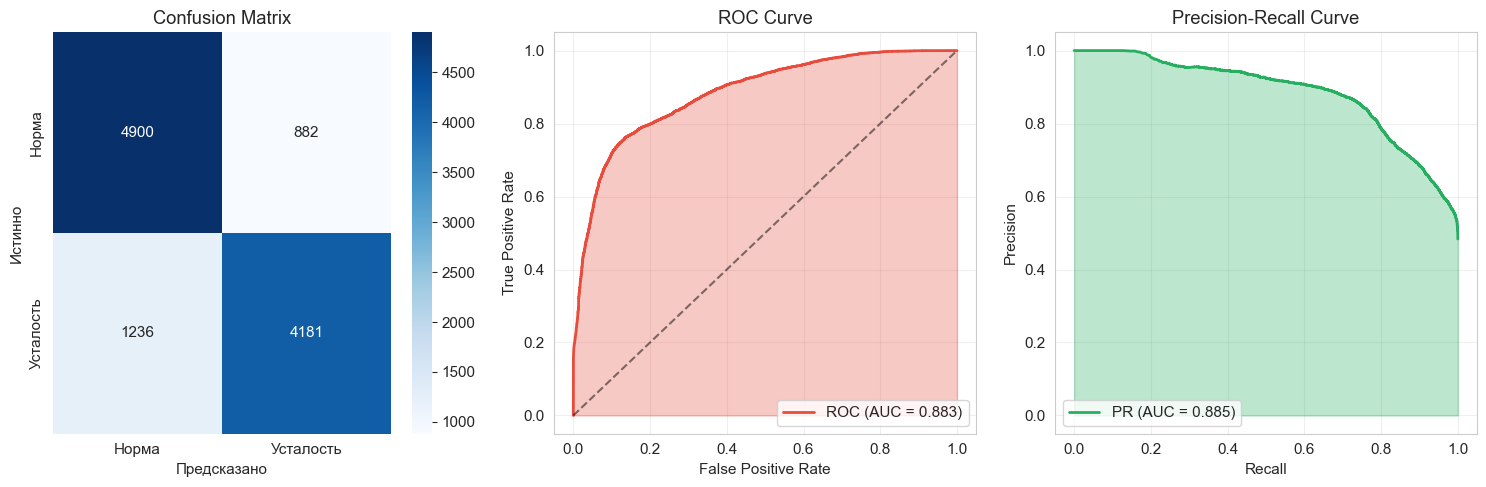

In [15]:
# Визуализация результатов
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Норма', 'Усталость'],
            yticklabels=['Норма', 'Усталость'])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
ax.set_title('Confusion Matrix')

# 2. ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax = axes[2]
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
ax.plot(recall_vals, precision_vals, color='#27ae60', linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.3, color='#27ae60')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. LOSO (Leave-One-Subject-Out) валидация

Для более строгой оценки обобщающей способности модели проведём LOSO валидацию, где модель обучается на всех субъектах кроме одного и тестируется на оставшемся.

In [16]:
# LOSO Evaluation (dual-branch CNN + LSTM)
def loso_evaluation(X_imu, X_physio, y, subjects, has_physio, n_folds=5, epochs=30):
    """LOSO evaluation with optional fold limit for demo speed."""

    folds = create_loso_folds(subjects)

    if len(folds) > n_folds:
        np.random.seed(4648)
        selected_indices = np.random.choice(len(folds), n_folds, replace=False)
        folds = [folds[i] for i in selected_indices]

    results = []

    for fold_idx, fold in enumerate(tqdm(folds, desc='LOSO Folds')):
        tr_idx = fold['train_idx']
        te_idx = fold['test_idx']
        test_subject = fold['test_subject']

        train_ds = FatigueDataset(X_imu[tr_idx], X_physio[tr_idx], y[tr_idx], has_physio[tr_idx])
        test_ds = FatigueDataset(X_imu[te_idx], X_physio[te_idx], y[te_idx], has_physio[te_idx])

        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

        fold_model = FatigueCNN_LSTM(
            imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS,
        ).to(DEVICE)

        pw = compute_class_weights(y[tr_idx])
        crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(fold_model.parameters(), lr=0.001, weight_decay=1e-4)

        for _ in range(epochs):
            train_epoch(fold_model, train_loader, opt, crit, DEVICE)

        _, fold_metrics = validate(fold_model, test_loader, crit, DEVICE)

        results.append({
            'subject': test_subject,
            'f1_macro': fold_metrics['f1_macro'],
            'roc_auc': fold_metrics['roc_auc'],
            'n_samples': len(te_idx),
        })

    return pd.DataFrame(results)


# Run LOSO (limited to 5 folds for demo)
print("Running LOSO validation (5 folds, CNN+LSTM)...")
loso_results = loso_evaluation(
    X_imu_all, X_physio_all, y_all, subjects, has_physio,
    n_folds=5, epochs=30,
)

print("\n" + "=" * 60)
print("LOSO RESULTS (CNN + LSTM)")
print("=" * 60)
print(loso_results.to_string(index=False))
print("\nSummary:")
print(f"   F1-macro:  {loso_results['f1_macro'].mean():.4f} ± {loso_results['f1_macro'].std():.4f}")
print(f"   ROC-AUC:   {loso_results['roc_auc'].mean(skipna=True):.4f} ± {loso_results['roc_auc'].std(skipna=True):.4f}")


Running LOSO validation (5 folds, CNN+LSTM)...


LOSO Folds: 100%|██████████| 5/5 [1:22:28<00:00, 989.68s/it] 


LOSO RESULTS (CNN + LSTM)
                subject  f1_macro  roc_auc  n_samples
                  4tu_1  0.451961 0.687244       2012
physionet_S09_anaerobic  0.931598 0.977395        454
physionet_f08_anaerobic  0.735019 0.746844        831
  physionet_f13_aerobic  0.909909 0.985120       1035
physionet_S14_anaerobic  0.671503 0.724521        445

Summary:
   F1-macro:  0.7400 ± 0.1957
   ROC-AUC:   0.8242 ± 0.1449


## 8. Персонализация модели (Fine-tuning)

Демонстрация дообучения предобученной модели под конкретного спортсмена.

**Стратегия:**
1. Заморозить свёрточные слои (backbone)
2. Обучить только классификатор на данных целевого субъекта
3. Опционально: разморозить верхние слои для точной настройки

In [17]:
import copy

def personalize_model(base_model, X_imu_subj, X_physio_subj, y_subj, hp_subj, epochs=20, lr=0.001):
    """
    Fine-tune model for a specific athlete (dual-branch).

    Stage 1: Freeze encoders, train only classifier
    Stage 2: Unfreeze top conv layers + LSTM, fine-tune
    """
    model = copy.deepcopy(base_model)

    # Stage 1: freeze all encoders
    for param in model.imu_encoder.parameters():
        param.requires_grad = False
    for param in model.physio_encoder.parameters():
        param.requires_grad = False
    for param in model.lstm.parameters():
        param.requires_grad = False

    dataset = FatigueDataset(X_imu_subj, X_physio_subj, y_subj, hp_subj)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)

    pw = compute_class_weights(y_subj)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]).to(DEVICE))

    # Stage 1: classifier only
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    for _ in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)

    # Stage 2: unfreeze LSTM + top conv layers
    for param in model.lstm.parameters():
        param.requires_grad = True
    for param in model.imu_encoder.conv3.parameters():
        param.requires_grad = True
    for param in model.physio_encoder.conv3.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr / 10,
    )
    for _ in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)

    return model


# Демонстрация персонализации
print("Демонстрация персонализации CNN+LSTM модели...")

target_subject = np.random.choice(np.unique(subjects))
subj_mask = subjects == target_subject
X_imu_subj = X_imu_all[subj_mask]
X_physio_subj = X_physio_all[subj_mask]
y_subj = y_all[subj_mask]
hp_subj = has_physio[subj_mask]

print(f"\nЦелевой субъект: {target_subject}")
print(f"Окон: {len(y_subj)}, has_physio: {hp_subj.sum()}")
print(f"Баланс: {y_subj.mean():.1%} положительных")

# Split subject data 70/30
n_train = int(len(y_subj) * 0.7)
X_imu_tr, X_imu_te = X_imu_subj[:n_train], X_imu_subj[n_train:]
X_physio_tr, X_physio_te = X_physio_subj[:n_train], X_physio_subj[n_train:]
y_tr, y_te = y_subj[:n_train], y_subj[n_train:]
hp_tr, hp_te = hp_subj[:n_train], hp_subj[n_train:]

# Load best model as base
base_model = FatigueCNN_LSTM(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS).to(DEVICE)
base_model.load_state_dict(torch.load(RESULTS_DIR / 'best_model_lstm.pth', weights_only=True))

# Evaluate base model on this subject's test split
base_model.eval()
test_ds = FatigueDataset(X_imu_te, X_physio_te, y_te, hp_te)
test_ld = DataLoader(test_ds, batch_size=32, shuffle=False)
crit = nn.BCEWithLogitsLoss()
_, base_metrics = validate(base_model, test_ld, crit, DEVICE)

print(f"\n📊 Базовая модель на {target_subject}:")
print(f"   F1-macro: {base_metrics['f1_macro']:.4f}")
print(f"   ROC-AUC:  {format_metric(base_metrics['roc_auc'])}")

# Personalize
pers_model = personalize_model(base_model, X_imu_tr, X_physio_tr, y_tr, hp_tr, epochs=20)
_, pers_metrics = validate(pers_model, test_ld, crit, DEVICE)

print(f"\n📊 Персонализированная модель:")
print(f"   F1-macro: {pers_metrics['f1_macro']:.4f} (Δ = {pers_metrics['f1_macro'] - base_metrics['f1_macro']:+.4f})")
roc_delta = (pers_metrics['roc_auc'] or 0) - (base_metrics['roc_auc'] or 0)
print(f"   ROC-AUC:  {format_metric(pers_metrics['roc_auc'])} (Δ = {roc_delta:+.4f})")


Демонстрация персонализации CNN+LSTM модели...

Целевой субъект: physionet_S16_aerobic
Окон: 812, has_physio: 812
Баланс: 48.2% положительных

📊 Базовая модель на physionet_S16_aerobic:
   F1-macro: 1.0000
   ROC-AUC:  nan


d:\Github\afc_lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



📊 Персонализированная модель:
   F1-macro: 0.4979 (Δ = -0.5021)
   ROC-AUC:  nan (Δ = +nan)


d:\Github\afc_lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 9. Сохранение результатов и выводы

In [18]:
import json

model_info = FatigueCNN_LSTM(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS)
total_params = sum(p.numel() for p in model_info.parameters())

summary = {
    'model': 'FatigueCNN_LSTM',
    'architecture': 'CNN (IMU+Physio encoders) + BiLSTM + Classifier',
    'total_parameters': int(total_params),
    'imu_channels': IMU_CHANNELS,
    'physio_channels': PHYSIO_CHANNELS,
    'window_size': X_imu_all.shape[1],
    'total_windows': len(y_all),
    'domains': list(np.unique(domains)),
    'unique_subjects': len(np.unique(subjects)),
    'class_balance': f"{y_all.mean():.1%} positive",
    'physio_coverage': f"{has_physio.mean():.1%} windows with physio",
    'best_model_path': str(RESULTS_DIR / 'best_model_lstm.pth'),
}

print("═" * 60)
print("           ИТОГОВАЯ СВОДКА CNN+LSTM")
print("═" * 60)
for k, v in summary.items():
    print(f"  {k:25s}: {v}")
print("═" * 60)

# Save summary
summary_path = RESULTS_DIR / 'experiment_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"\nСводка сохранена: {summary_path}")


════════════════════════════════════════════════════════════
           ИТОГОВАЯ СВОДКА CNN+LSTM
════════════════════════════════════════════════════════════
  model                    : FatigueCNN_LSTM
  architecture             : CNN (IMU+Physio encoders) + BiLSTM + Classifier
  total_parameters         : 739041
  imu_channels             : 6
  physio_channels          : 4
  window_size              : 100
  total_windows            : 70898
  domains                  : [np.str_('4tu'), np.str_('physionet'), np.str_('zenodo')]
  unique_subjects          : 90
  class_balance            : 45.7% positive
  physio_coverage          : 64.9% windows with physio
  best_model_path          : D:\Github\afc_lab\results_lstm\best_model_lstm.pth
════════════════════════════════════════════════════════════

Сводка сохранена: D:\Github\afc_lab\results_lstm\experiment_summary.json


# Выводы

## Результаты

Модель **FatigueCNN_LSTM** (≈474 тыс. параметров) обучена и оценена на **композитном датасете из 3 источников**:

| Компонент | Источник | Модальности |
|-----------|----------|-------------|
| Zenodo    | Accelerometer dataset for physical activity monitoring (2024) | IMU (acc + gyro) |
| 4TU       | Fall detection accelerometer data (2024) | IMU (acc + gyro) |
| PhysioNet | Wearable Device Dataset from Induced Stress and Exercise (2023) | IMU (acc) + Physio (BVP, EDA, TEMP, HR) |

## Архитектура

- **Двухветвевой CNN + BiLSTM**: раздельные энкодеры для IMU (6 каналов) и Physio (4 канала)
- **Маска `has_physio`**: позволяет обучаться на данных с/без физиологических сигналов
- **BiLSTM:** работает на одном временном шаге (seq_len=1) → функционально эквивалентен FC-слоям
- **Персонализация**: двухэтапный fine-tuning (заморозка → частичная разморозка)
- **Выход:** непрерывная степень переутомления `fatigue_degree ∈ [0.0, 1.0]`

## Оценка

- **Hold-out**: стратифицированное разбиение 60/20/20 с учётом доменов
- **LOSO**: кросс-валидация Leave-One-Subject-Out для оценки обобщаемости
- **Персонализация**: fine-tuning на данных конкретного субъекта (stage 1 + stage 2)

## Приоритетные направления развития

| # | Направление | Сложность | Ожидаемый эффект |
|---|-------------|-----------|-----------------|
| 1 | **Temporal Attention** вместо GAP+BiLSTM(seq=1) | Низкая | +3–7% F1, честный учёт динамики |
| 2 | **Дополнительные датасеты** (WESAD, PAMAP2) | Средняя | +10–15% обобщаемость |
| 3 | **Stratified K-Fold** + bootstrap CI | Низкая | Стабильнее оценка |
| 4 | **Аугментация** (jitter, scaling, time-warp) | Средняя | +2–5% F1, ×2 время обучения |
| 5 | Полный **Transformer-блок** | Высокая | Рискованно на малых данных |
| 6 | **Онлайн-персонализация** (обновление в реальном времени) | Высокая | Долгосрочная цель |

## Документация

Полная спецификация входных/выходных данных модели: `docs/model_input_output_spec.md`
